### Your Task : Create a comprehensive visual analysis of the car sales dataset using different plotting libraries.

Dataset Columns:

- Price: Sale price of the vehicle
- Years: Vehicle registration year
- Brand: Car brand
- Model: Car model
- Color: Vehicle color
- State/City: Sale location
- Mileage: Miles traveled
- Vin: Vehicle identification number
- Title Status: Clean title or salvage insurance
- Lot: Lot number
- Condition: Vehicle condition

Create a histogram showing the distribution of car prices.

Create a box plot showing price distribution by brand (top 10 brands).

Create an interactive scatter plot of Price vs. Mileage, color-coded by Condition.

Optional : create a heatmap of average prices by brand and condition.


### Solution

In [325]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import plotly.express as px



In [300]:
# Basic workflow
df = pd.read_csv('data/USA_cars_datasets.csv')

df.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [301]:
df.shape

(2499, 13)

In [302]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2499 non-null   int64  
 1   price         2499 non-null   int64  
 2   brand         2499 non-null   str    
 3   model         2499 non-null   str    
 4   year          2499 non-null   int64  
 5   title_status  2499 non-null   str    
 6   mileage       2499 non-null   float64
 7   color         2499 non-null   str    
 8   vin           2499 non-null   str    
 9   lot           2499 non-null   int64  
 10  state         2499 non-null   str    
 11  country       2499 non-null   str    
 12  condition     2499 non-null   str    
dtypes: float64(1), int64(4), str(8)
memory usage: 253.9 KB


In [303]:
df.describe()

,Unnamed: 0,price,year,mileage,lot
count,2499.000000,2499.000000,2499.000000,2.499000e+03,2.499000e+03
mean,1249.000000,18767.671469,2016.714286,5.229869e+04,1.676914e+08
std,721.543484,12116.094936,3.442656,5.970552e+04,2.038772e+05
min,0.000000,0.000000,1973.000000,0.000000e+00,1.593488e+08
25%,624.500000,10200.000000,2016.000000,2.146650e+04,1.676253e+08
50%,1249.000000,16900.000000,2018.000000,3.536500e+04,1.677451e+08
75%,1873.500000,25555.500000,2019.000000,6.347250e+04,1.677798e+08
max,2498.000000,84900.000000,2020.000000,1.017936e+06,1.678055e+08


In [304]:
# Drop irrelevant columns

df = df.drop(columns=['Unnamed: 0'])

In [305]:
# Check duplicated rows
print(f'duplicated rows: {df.duplicated().sum()}')

duplicated rows: 0


In [306]:
# Check nulls:
print(f'null values:')
df.isnull().sum()

null values:


price           0
brand           0
model           0
year            0
title_status    0
mileage         0
color           0
vin             0
lot             0
state           0
country         0
condition       0
dtype: int64

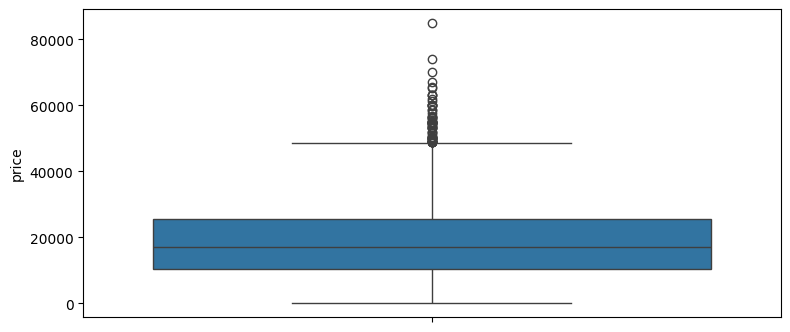

In [307]:
# Check outliers for car price using boxplot
fig, ax = plt.subplots(figsize=(9,4))

sns.boxplot(data=df['price'])
plt.show()

In [308]:
# Calculate number of outliers
# Calculate Q1, Q3, and IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers (boolean mask)
outliers_mask = (df['price'] < lower_bound) | (df['price'] > upper_bound)

# Display the outliers
outliers = df[outliers_mask]
percentage = (len(outliers) / len(df)) * 100
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {round(percentage)}%")


Number of outliers: 64
Percentage of outliers: 3%


In [309]:
# Replace outliers

# Mask outliers as NaN
df.loc[(df['price'] < lower_bound) | (df['price'] > upper_bound), 'price'] = np.nan

# Apply Imputer
imputer = SimpleImputer(strategy='median')
df['price'] = imputer.fit_transform(df[['price']])

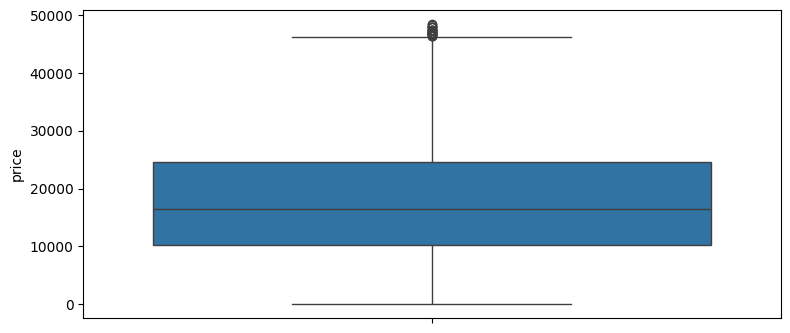

In [310]:
# Check outliers for car price using boxplot after imputing
fig, ax = plt.subplots(figsize=(9,4))

sns.boxplot(data=df['price'])
plt.show()

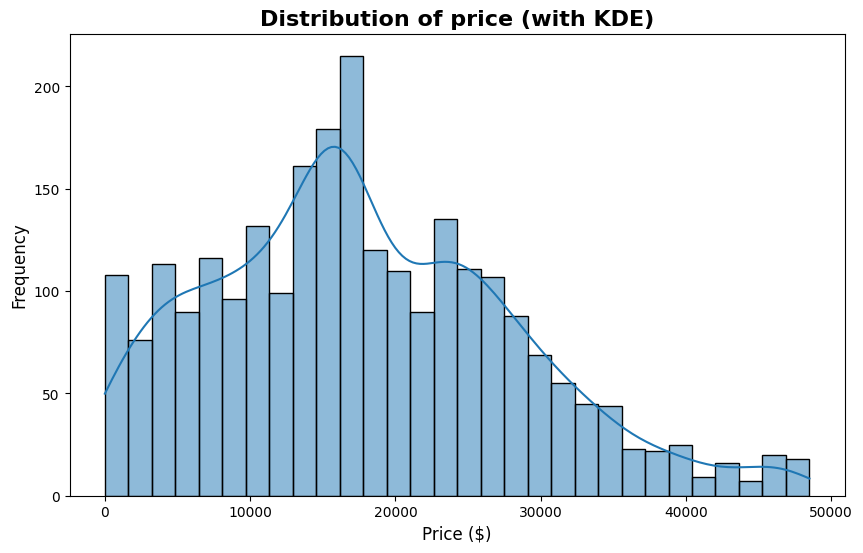

In [311]:
# Create Histogram for car prices
plt.figure(figsize=(10,6))

sns.histplot(data=df['price'], bins=30, kde=True)

plt.title('Distribution of price (with KDE)', fontsize=16, fontweight='bold')
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

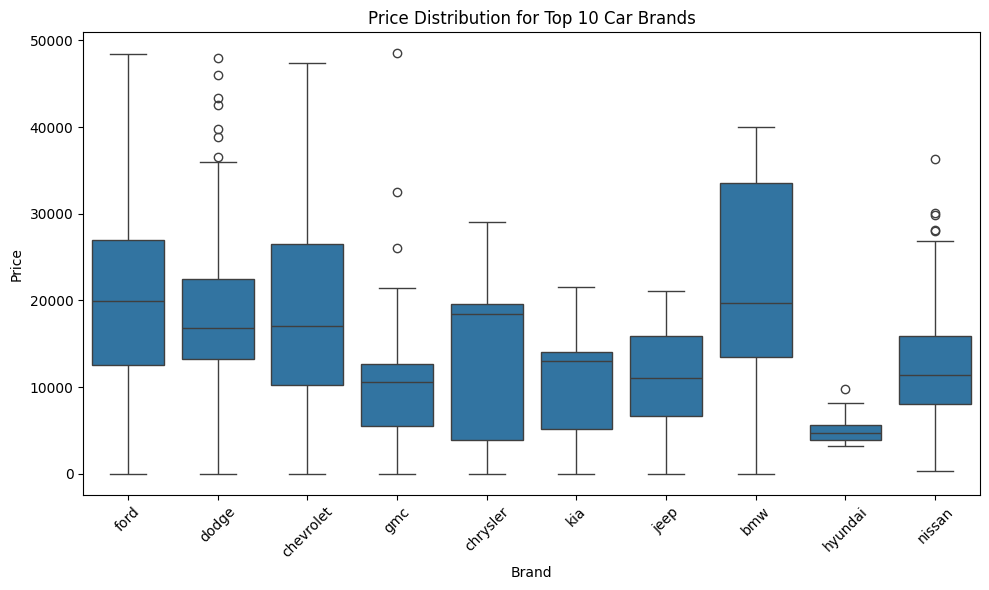

In [ ]:
# Get Top 10 Brands
top_10_brands = df["brand"].value_counts().head(10).index
top_10_brands

# Filter the DataFrame
df_top10 = df[df["brand"].isin(top_10_brands)]

# Create Boxplots
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_top10,
    x="brand",
    y="price"
)

plt.xticks(rotation=45)
plt.title("Price Distribution for Top 10 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [ ]:
# Create scatter plot
fig = px.scatter(df, x='price', y='mileage')
fig.update_layout(title='Price vs Mileage',
                 xaxis_title='Price ($)',
                 yaxis_title='Mileage (miles)',
                 template='seaborn')
fig.show()